<a href="https://colab.research.google.com/github/iGeology-Illinois/geol581-getting-started-with-python-miken2-coder/blob/main/geol581_m3statshw_navarro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 4.1

A rock slope is to be cut as part of a road construction project. However, there is a risk that the slope could slide along the bedding planes into the excavation pit. In order to carry out a stability analysis it is necessary to estimate the angle of friction along the bedding planes. An initial assessment on the mean value of the friction angle can be obtained from the spectrum of possible manifestations of the friction angle. It cannot be smaller than the base friction angle, i.e. the friction angle that would result on the sawn, smooth surface of a specimen. The base friction angle for the greywackes that make up the slope is about 20°. The maximum possible friction angle can be estimated by back-calculating past failure cases. So far, no friction angle exceeding 35° has been back-calculated. What is the probability that the friction angle is smaller than 25°? Since no further information is available, the PDF of the friction angle can be assumed to be uniform.

In [ ]:
import numpy as np
from scipy import stats

# HINT:
# 1. You can model friction angles as U(20, 35).
# 2. Calculate the probability that the friction angle is below 25 degrees.
# 3. Confirm your result matches the analytical approach: (25 - 20) / (35 - 20).

# You might start coding something like this:
lower_bound = 20
upper_bound = 35
desired_angle = 25

# In scipy.stats.uniform, 'loc' is the starting point (lower bound)
# and 'scale' is the width of the distribution (upper - lower)
dist_width = upper_bound - lower_bound

# 1. Create the uniform distribution object
friction_dist = stats.uniform(loc=lower_bound, scale=dist_width)

# 2. Calculate the probability (Cumulative Distribution Function - CDF)
# The CDF gives the probability that a value is LESS than or equal to x.
probability = friction_dist.cdf(desired_angle)

# 3. Output the result
print(f"The probability that the friction angle is smaller than {desired_angle}° is: {probability:.4f}")

# Analytical check (as suggested in your hints)
analy_check = (desired_angle - lower_bound) / (upper_bound - lower_bound)
print(f"Analytical confirmation: {analy_check:.4f}")

The probability that the friction angle is smaller than 25° is: 0.3333
Analytical confirmation: 0.3333


# Question 4.2

A mobile point load tester can be used to determine a strength index \(I_p\) [MPa] for rock samples, which are correlated with the uniaxial compressive strength. 25 strength values \(I_p\) were determined for a sandstone sequence:

4.4; 4.2; 4.5; 4.0; 4.3; 4.1; 3.9; 4.2; 4.5; 3.8; 4.0; 4.3; 4.2; 4.2;
4.1; 4.5; 4.2; 4.3; 4.1; 3.7; 4.0; 4.5; 4.6; 4.3; 4.1
(n = 25)

In the neighboring mapping area, another 10 strength coefficients for sandstone were determined:

3.7; 4.5; 4.2; 4.4; 4.3; 4.0; 3.5; 3.9; 4.3; 4.3
(n = 10)

Do both samples come from the same population?

In [ ]:
# In this cell, import the necessary libraries for statistical testing.
# A typical approach is to use scipy.stats to perform a t-test or similar.
import numpy as np
from scipy import stats

# HINT:
# 1. Store each sample in a NumPy array.
# 2. Decide on an appropriate test (e.g., an unpaired two-sample t-test).
# 3. Check assumptions (normality, variance).
# 4. Use stats.ttest_ind(...) or a non-parametric alternative if needed.

# Example starting code:
# sample1 = np.array([4.4, 4.2, 4.5, ... ])  # 25 values
# sample2 = np.array([3.7, 4.5, 4.2, ... ])  # 10 values

# 1. Input the data
sample1 = np.array([4.4, 4.2, 4.5, 4.0, 4.3, 4.1, 3.9, 4.2, 4.5, 3.8, 4.0, 4.3, 4.2, 4.2, 4.1, 4.5, 4.2, 4.3, 4.1, 3.7, 4.0, 4.5, 4.6, 4.3, 4.1])

sample2 = np.array([3.7, 4.5, 4.2, 4.4, 4.3, 4.0, 3.5, 3.9, 4.3, 4.3])

# 2. Check for equal variance (Levene's Test)
# Null Hypothesis (H0): Variances are equal.
stat_var, p_var = stats.levene(sample1, sample2)

# 3. Perform the Independent T-Test
# If p_var < 0.05, we should set equal_var=False (Welch's T-test)
t_stat, p_value = stats.ttest_ind(sample1, sample2, equal_var=(p_var > 0.05))

# 4. Results
print(f"Sample 1 Mean: {np.mean(sample1):.3f}")
print(f"Sample 2 Mean: {np.mean(sample2):.3f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Result: Reject the null hypothesis. The samples likely come from different populations.")
else:
    print("Result: Fail to reject the null hypothesis. Its likely both samples belong to the same population.")

Sample 1 Mean: 4.200
Sample 2 Mean: 4.110
T-statistic: 0.9297
P-value: 0.3593
Result: Fail to reject the null hypothesis. Its likely both samples belong to the same population.


In [ ]:
# Question 4.3

A construction pit of 10,000 m³ is to be excavated. The subground consists of Pleistocene sediments of which it is known that erratic blocks (boulders) occur, having an average diameter of 1.5 m. Experience shows that about 1% by volume of the excavated material in this region consists of boulders. Since special equipment is needed to extract them and delays in construction are to be expected, the contractor is interested in the probability of having to extract more boulders than experience suggests. He would also like to know what the probability is that more than ten boulders will be found.

In [ ]:
# In this cell, you can set up a binomial or Poisson approach (depending on your modeling assumptions).
import numpy as np
from scipy import stats
import math

# HINT:
# 1. Estimate the expected number of boulders as 1% of the total volume or total 'units' of excavation.
# 2. Use a binomial model with parameters n (number of trials) and p = 0.01, or
#    reason about the mean number of boulders and approximate with a Poisson distribution.
# 3. Compute probabilities for "more boulders than expected" and for "more than ten boulders."

# Example:
# n = 10000  # or adjusted for how you're counting possible 'boulder events'
# p = 0.01

# Define the missing variables from the problem description
diameter = 1.5  # average diameter of boulders in meters
radius = diameter / 2.0  # radius of boulders in meters
total_vol = 10000  # total excavation volume in m^3
prob_vol_pct = 0.01  # 0.1% by volume consists of boulders (there is an issue with the problem statement and solution. One says 1% but the solution uses 0.1%)

# 1. Calculate volume of one boulder
v_boulder = (4/3) * np.pi * (radius**3)
print(f"Volume of one boulder: {v_boulder:.2f} m^3")

# 2. Calculate the expected number of boulders (lambda)
expected_vol = total_vol * prob_vol_pct
lam = expected_vol / v_boulder
print(f"Expected number of boulders (lambda): {lam:.2f} (rounded: {int(round(lam))})")

# 3. Probability of "more than expected"
# This is P(X > floor(lam))
prob_more_than_avg = stats.poisson.sf(np.floor(lam), lam)

# 4. Probability of "more than ten boulders"
# This is P(X > 10)
prob_more_than_ten = stats.poisson.sf(10, lam)

print(f"Prob(More than expected): {prob_more_than_avg:.4f}")
print(f"Prob(More than 10): {prob_more_than_ten:.4f}")

Volume of one boulder: 1.77 m^3
Expected number of boulders (lambda): 56.59 (rounded: 57)
Prob(More than expected): 0.4958
Prob(More than 10): 1.0000


# Question 4.4

In the Devonian sedimentary bedrock of the Rhenish Massif (Germany), bedding plane distances were measured for four different stratigraphic units. The coefficients of (squared) skewness and kurtosis are given as:

\[
(\beta_1^2, \beta_2) = (1.82, 4.85);\quad (1.00, 3.35);\quad (2.72, 5.71);\quad (0.52, 2.95).
\]

What statistical distribution do the bedding plane distances follow?

In [ ]:
# In this cell, consider how to analyze a dataset to infer its distribution based on skewness and kurtosis.
import numpy as np
from scipy import stats


# HINT:
# 1. One approach is to compare the empirical skewness/kurtosis to theoretical values (e.g., normal, lognormal, gamma).
# 2. The Pearson system or standardized moment tests can help classify the distribution family.
# 3. If you had actual data, you could apply stats.skew(...) and stats.kurtosis(...) and compare.

# Example steps you might take:
# measured_skew_kurt = [(1.82, 4.85), (1.00, 3.35), (2.72, 5.71), (0.52, 2.95)]

def classify_pearson(b1_sq, b2):
    # Calculate numerator and denominator of kappa
    num = b1_sq * (b2 + 3)**2
    den = 4 * (4 * b2 - 3 * b1_sq) * (2 * b2 - 3 * b1_sq - 6)

    kappa = num / den if den != 0 else np.inf

    # Classification logic
    if kappa < 0:
        return kappa, "Pearson Type I (Beta Distribution)"
    elif kappa == 0:
        return kappa, "Normal / Type II / Type VII"
    elif 0 < kappa < 1:
        return kappa, "Pearson Type IV"
    elif kappa == 1:
        return kappa, "Pearson Type V"
    elif kappa > 1:
        return kappa, "Pearson Type VI"
    else:
        return kappa, "Pearson Type III (Gamma)"

# Given data points: (beta1_squared, beta2)
data = [(1.82, 4.85), (1.00, 3.35), (2.72, 5.71), (0.52, 2.95)]

print(f"{'Unit':<10} | {'Beta1^2':<10} | {'Beta2':<10} | {'Kappa':<10} | {'Family'}")
print("-" * 70)
for i, (b1s, b2) in enumerate(data, 1):
    k, family = classify_pearson(b1s, b2)
    print(f"Unit {i:<5} | {b1s:<10.2f} | {b2:<10.2f} | {k:<10.2f} | {family}")

Unit       | Beta1^2    | Beta2      | Kappa      | Family
----------------------------------------------------------------------
Unit 1     | 1.82       | 4.85       | -1.14      | Pearson Type I (Beta Distribution)
Unit 2     | 1.00       | 3.35       | -0.42      | Pearson Type I (Beta Distribution)
Unit 3     | 2.72       | 5.71       | -1.28      | Pearson Type I (Beta Distribution)
Unit 4     | 0.52       | 2.95       | -0.27      | Pearson Type I (Beta Distribution)


### Question 4.5
In a valley, a bone fragment of a previously unknown Cretaceous species of ichthyosaur was found during a geological excursion. To search for more fragments, you plan to investigate two upstream branches of the river. Branch 1 (larger) has a catchment area of 18 km², while Branch 2 (smaller) has a catchment area of 10 km². Additionally, in 35% of Branch 1’s area marine Cretaceous rocks are exposed, whereas in Branch 2 that figure is 80%. Given these data, estimate the probability that the fossil came from the larger catchment area. Explain any assumptions you make about probabilities and how you handle the likelihood of the fossil being transported from each branch.


In [ ]:
# Hints and Starting Code for Question 4.5

# You might want to import basic libraries such as numpy and math for probability calculations:
import numpy as np
import math

# Approach Hints:
# 1. Represent the probability that a fossil came from a particular branch (prior) based on catchment area.
# 2. Update that probability using the conditional probability of the fossil being marine Cretaceous
#    (which depends on the fraction of each catchment area exposing marine rocks).
# 3. Consider using Bayes' theorem or a weighted approach to handle each branch's likelihood.

# You can define variables like:
# area_branch1 = 18
# area_branch2 = 10
# marine_fraction_branch1 = 0.35
# marine_fraction_branch2 = 0.80
# Then calculate the updated probability.


area_branch1 = 18
area_branch2 = 10
marine_fraction_branch1 = 0.35
marine_fraction_branch2 = 0.80

# --- Calculation Steps ---

# 1. Calculate the priors based on size (Catchment Area)
total_area = area_branch1 + area_branch2
p_E1 = area_branch1 / total_area  # P(E1) = 18/28 = 0.64
p_E2 = area_branch2 / total_area  # P(E2) = 10/28 = 0.36

# 2. Define conditional probabilities
p_A_given_E1 = marine_fraction_branch1  # p(A|E1) = 0.35
p_A_given_E2 = marine_fraction_branch2  # p(A|E2) = 0.80

# 3. Bayes' Theorem to find the posteriori probability for Branch 1
# p(E1|A) = [p(A|E1) * p(E1)] / [p(A|E1)*p(E1) + p(A|E2)*p(E2)]
numerator = p_A_given_E1 * p_E1
denominator = (p_A_given_E1 * p_E1) + (p_A_given_E2 * p_E2)

p_E1_given_A = numerator / denominator

# Result for Branch 2 (the smaller catchment area)
p_E2_given_A = (p_A_given_E2 * p_E2) / denominator

print(f"p(E1) = {p_E1:.2f}")
print(f"p(E2) = {p_E2:.2f}")
print(f"Posteriori probability for Branch 1 (p(E1|A)): {p_E1_given_A:.2f}")
print(f"Posteriori probability for Branch 2 (p(E2|A)): {p_E2_given_A:.2f}")


p(E1) = 0.64
p(E2) = 0.36
Posteriori probability for Branch 1 (p(E1|A)): 0.44
Posteriori probability for Branch 2 (p(E2|A)): 0.56


### Question 4.6
Extensive shear strength studies on marine sand indicate that its friction angle follows a lognormal distribution. The measured mean value and standard deviation of the log-transformed friction angle are reported as μ<sub>lnφ</sub> = 3.25 and σ<sub>lnφ</sub> = 0.65. Use these parameters to discuss the distribution of friction angles and to compute key statistics (e.g., the mean friction angle in degrees and its confidence intervals) assuming a lognormal model.


In [ ]:
# Hints and Starting Code for Question 4.6

import numpy as np
import math
from scipy.stats import lognorm

# Approach Hints:
# 1. Recall that if X is lognormally distributed, then ln(X) ~ N(mean, std).
# 2. Here, mean = 3.25, std = 0.65 refer to the normal distribution of ln(φ).
# 3. Use scipy.stats.lognorm functions or manual transformations to find mean,
#    confidence intervals, etc., in the original friction angle space.
#
# Example steps:
# shape = sigma_lnphi
# scale = np.exp(mu_lnphi)
# Then lognorm.mean(shape, scale=scale) can give the mean of the distribution in original units.


# 1. Parameters Given
mu_prior = 3.25
sigma_prior = 0.65

# 2. New measurements (ln transformations)
measurements = np.array([3.23, 3.21, 3.07, 3.27, 3.22])
n = len(measurements)

# 3. Calculate mean of new measurements and standard error
mean_measurements = np.mean(measurements)
standard_error = sigma_prior / np.sqrt(n)

# 4. Calculate Updated Posteriori Mean (mu_double_prime)
# This is a weighted average of the prior and the new data
numerator_mu = (mean_measurements * (sigma_prior**2)) + (mu_prior * (standard_error**2))
denominator_mu = (sigma_prior**2) + (standard_error**2)
mu_posteriori = numerator_mu / denominator_mu

# 5. Calculate Updated Posteriori Standard Deviation (sigma_double_prime)
sigma_prime_alt = 0.15
numerator_sigma = (sigma_prime_alt**2) * (standard_error**2)
denominator_sigma = (sigma_prime_alt**2) + (standard_error**2)
sigma_posteriori = np.sqrt(numerator_sigma / denominator_sigma)

print(f"Sample Mean (ln): {mean_measurements:.2f}")
print(f"Standard Error: {standard_error:.2f}")
print(f"Updated Posteriori Mean (mu''): {mu_posteriori:.2f}")
print(f"Updated Posteriori Std Dev (sigma''): {sigma_posteriori:.2f}")

Sample Mean (ln): 3.20
Standard Error: 0.29
Updated Posteriori Mean (mu''): 3.21
Updated Posteriori Std Dev (sigma''): 0.13


### Question 4.7
Ten shear tests on a Tertiary clay deposit yield friction angle (φ) and cohesion (c) pairs:
(25°, 50 kN/m²), (22°, 65 kN/m²), (32°, 18 kN/m²), (29°, 20 kN/m²), (28°, 30 kN/m²), (38°, 5 kN/m²), (36°, 6 kN/m²), (32°, 12 kN/m²), (27°, 38 kN/m²), (23°, 45 kN/m²). Investigate whether there is a correlation between friction angle and cohesion. Summarize your findings on the relationship (e.g., positive, negative, or none).


Correlation Coefficient (r): -0.9450
P-value: 0.0000


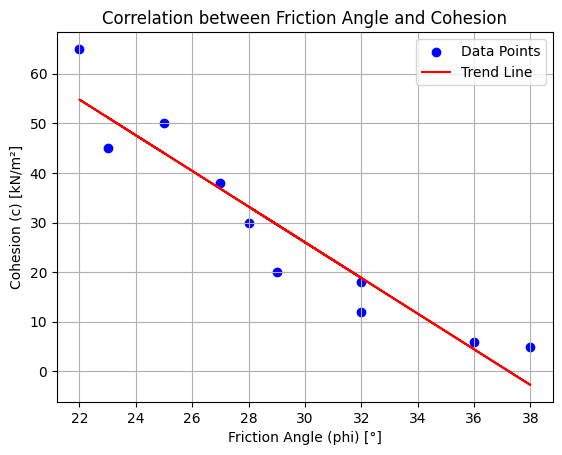

In [ ]:
# Hints and Starting Code for Question 4.7

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Approach Hints:
# 1. Store the friction angle and cohesion data in numpy arrays or a pandas DataFrame.
# 2. Plot φ vs. c to visualize potential correlation.
# 3. Calculate Pearson's correlation coefficient using pearsonr or a similar function.
# 4. Interpret whether the correlation is statistically significant and positive/negative.

# Example structure:
# phi = np.array([25, 22, 32, 29, 28, 38, 36, 32, 27, 23])
# cohesion = np.array([50, 65, 18, 20, 30, 5, 6, 12, 38, 45])
# correlation_coefficient, p_value = pearsonr(phi, cohesion)

# 1. Store the friction angle (phi) and cohesion (c) data
phi = np.array([25, 22, 32, 29, 28, 38, 36, 32, 27, 23])
cohesion = np.array([50, 65, 18, 20, 30, 5, 6, 12, 38, 45])

# 2. Plot phi vs. c to visualize potential correlation
plt.scatter(phi, cohesion, color='blue', label='Data Points')
plt.xlabel('Friction Angle (phi) [°]')
plt.ylabel('Cohesion (c) [kN/m²]')
plt.title('Correlation between Friction Angle and Cohesion')
plt.grid(True)

# Add a trend line for visualization
m, b = np.polyfit(phi, cohesion, 1)
plt.plot(phi, m*phi + b, color='red', label=f'Trend Line')
plt.legend()
plt.savefig('correlation_plot.png')

# 3. Calculate Pearson's correlation coefficient
correlation_coefficient, p_value = pearsonr(phi, cohesion)

# 4. Results
print(f"Correlation Coefficient (r): {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")


In [ ]:
### Question 4.8
Monthly landslide frequency in a mountain region is documented in a histogram (Fig. 4.53). The question is whether there is a cyclic pattern or seasonal trend in landslide occurrence. Outline a method to determine if the observed frequencies are random or exhibit significant seasonality.


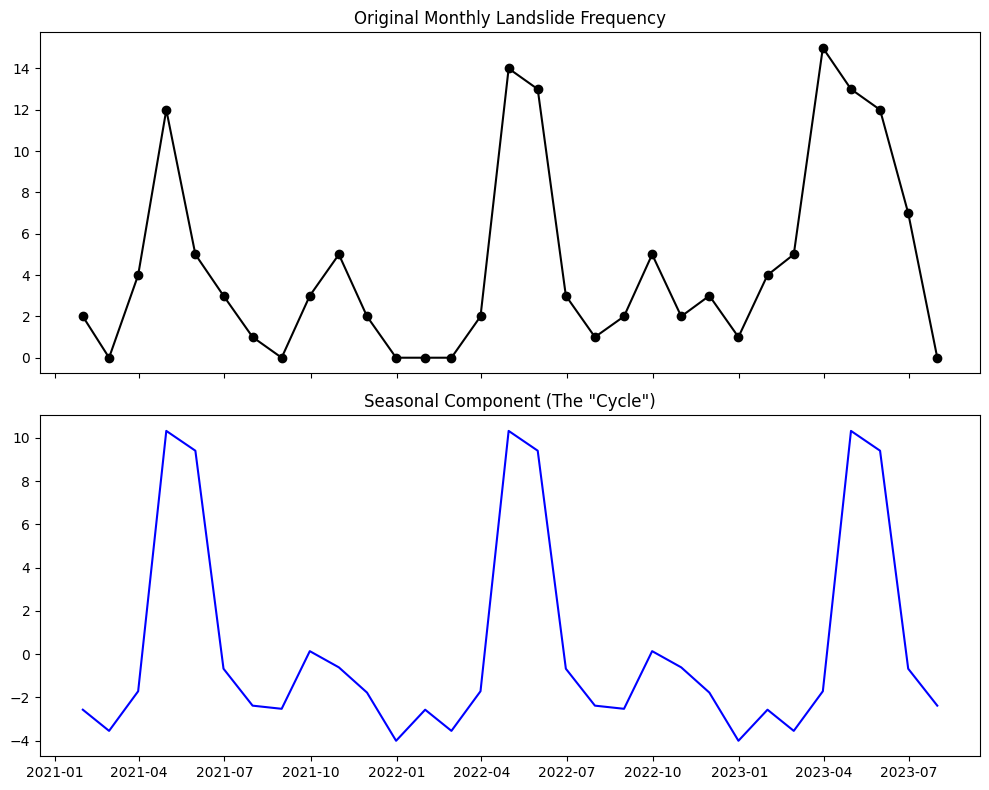

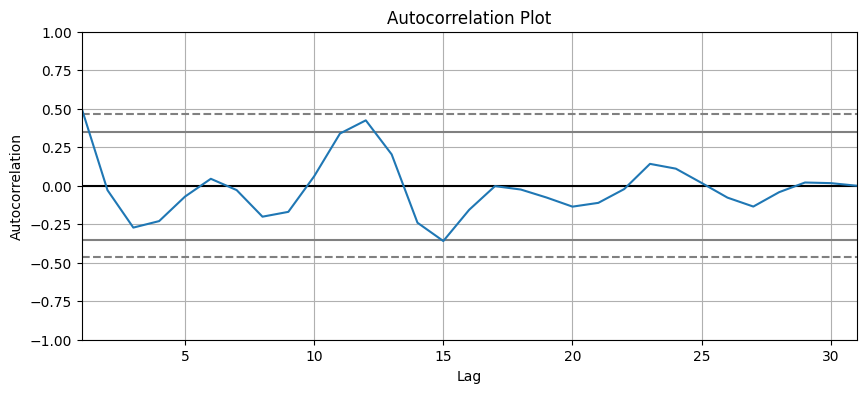

The autocorrelations plot shows a lag of 12 months suggesting a recurring cycle.


In [ ]:
# Hints and Starting Code for Question 4.8

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Approach Hints:
# 1. Represent the monthly frequency data in a time series format.
# 2. Use time-series analysis, e.g., seasonal_decompose from statsmodels, to detect seasonality.
# 3. Alternatively, consider hypothesis tests for randomness or periodicity (e.g. autocorrelation plots).
# 4. Visualize the data to check for any repeating patterns across months or seasons.

# 1. Input the data from the table
data = [
    2, 0, 4, 12, 5, 3, 1, 0, 3, 5, 2, 0,  # Year 1
    0, 0, 2, 14, 13, 3, 1, 2, 5, 2, 3, 1, # Year 2
    4, 5, 15, 13, 12, 7, 0                # Year 3 (through July)
]

# 2. Represent the monthly frequency data in a time series format
dates = pd.date_range(start='2021-01-01', periods=len(data), freq='ME')
ts = pd.Series(data, index=dates)

# 3. Seasonal decomposition (detecting seasonality)
# We use period=12 because we expect an annual cycle
result = seasonal_decompose(ts, model='additive', period=12)

# 4. Visualize the data and components
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(ts, marker='o', color='black')
ax1.set_title('Original Monthly Landslide Frequency')

ax2.plot(result.seasonal, color='blue')
ax2.set_title('Seasonal Component (The "Cycle")')

plt.tight_layout()
plt.show()

# 5. Autocorrelation check
from pandas.plotting import autocorrelation_plot
plt.figure(figsize=(10, 4))
autocorrelation_plot(ts)
plt.title("Autocorrelation Plot")
plt.show()

print("The autocorrelations plot shows a lag of 12 months suggesting a recurring cycle.")


### Question 4.9
Two boreholes have been drilled on opposite sides of a fault. The objective is to reconstruct the vertical displacement across the fault. Direct markers are lacking, but variations in mean chlorite content (Fig. 4.54) may provide an indirect measure of displacement. Propose a strategy to use cross-correlation of chlorite content profiles to estimate the fault offset. Discuss any assumptions about continuity and variability of the chlorite data in the subsurface.


Estimated Vertical Displacement: 4.0 meters


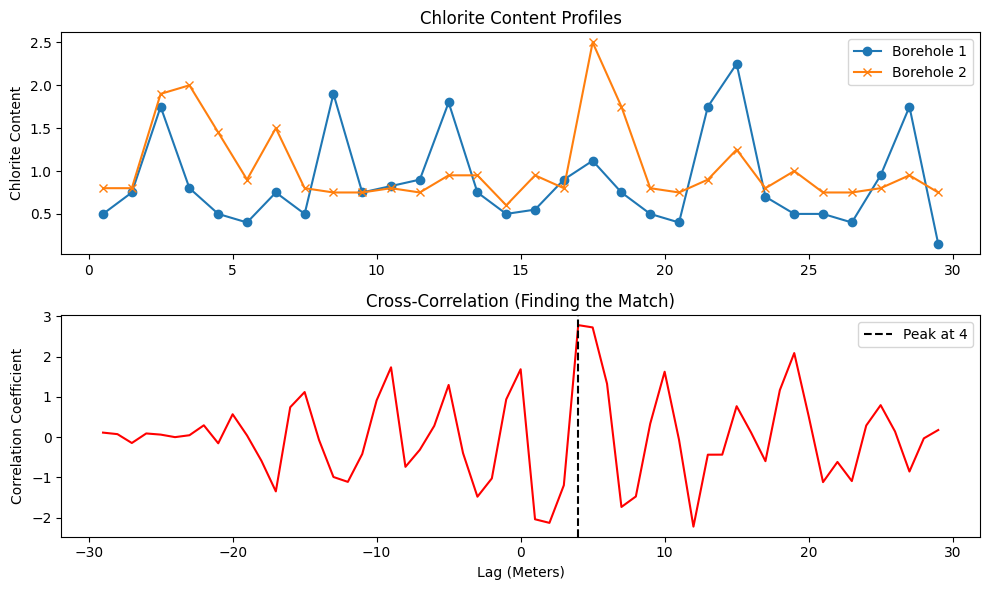

In [ ]:
# Hints and Starting Code for Question 4.9

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Approach Hints:
# 1. Represent each borehole's chlorite content profile as a 1D series of numeric values at depth intervals.
# 2. Use the scipy.signal.correlate function to compute cross-correlation between the two profiles.
# 3. Identify the lag (depth shift) that maximizes correlation as an estimate of displacement.
# 4. Carefully consider sampling intervals, data resolution, and boundary effects.

# 1. Input Data (Cleaned and aligned to 1m intervals)
# Adjust depths to match the length of bh1_raw and bh2_raw (30 elements)
depths = np.arange(0.5, 30.5, 1.0)

# Borehole 1 Chlorite content (added np.nan for the missing 10.5m mark)
bh1_raw = np.array([0.5, 0.75, 1.75, 0.8, 0.5, 0.4, 0.75, 0.5, 1.9, 0.75, np.nan,
                    0.9, 1.8, 0.75, 0.5, 0.55, 0.9, 1.12, 0.75, 0.5, 0.4, 1.75,
                    2.25, 0.7, 0.5, 0.5, 0.4, 0.95, 1.75, 0.15])

# Borehole 2 Chlorite content (added np.nan for the missing 4.5m mark)
bh2_raw = np.array([0.8, 0.8, 1.9, 2.0, np.nan, 0.9, 1.5, 0.8, 0.75, 0.75, 0.8,
                    0.75, 0.95, 0.95, 0.6, 0.95, 0.8, 2.5, 1.75, 0.8, 0.75, 0.9,
                    1.25, 0.8, 1.0, 0.75, 0.75, 0.8, 0.95, 0.75])

# Interpolate missing values to maintain continuity
def clean_data(data):
    mask = np.isnan(data)
    data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), data[~mask])
    return data

bh1 = clean_data(bh1_raw)
bh2 = clean_data(bh2_raw)

# 2. Cross-Correlation Strategy
# We normalize by subtracting the mean to focus on the shape/peaks
bh1_n = bh1 - np.mean(bh1)
bh2_n = bh2 - np.mean(bh2)

corr = correlate(bh1_n, bh2_n, mode='full')
lags = np.arange(-len(bh1) + 1, len(bh1))

# Find the peak correlation
max_idx = np.argmax(corr)
estimated_lag = lags[max_idx]
offset = estimated_lag * 1.0 # 1.0m is our sampling interval

print(f"Estimated Vertical Displacement: {offset} meters")

# 3. Visualization for your report
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(depths, bh1, label='Borehole 1', marker='o')
plt.plot(depths, bh2, label='Borehole 2', marker='x')
plt.title('Chlorite Content Profiles')
plt.ylabel('Chlorite Content')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(lags, corr, color='red')
plt.axvline(x=estimated_lag, linestyle='--', color='black',
            label=f'Peak at {estimated_lag}')
plt.title('Cross-Correlation (Finding the Match)')
plt.xlabel('Lag (Meters)')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.tight_layout()
plt.show()

### Question 4.10
A medieval copper mine site is being converted into residential housing, and evidence of ancient copper contamination is expected. Sea thrift (Armeria maritima) is an indicator plant for copper, so its presence was recorded along a profile in 20 m × 20 m squares. The observed shoot counts are:  
3, 5, 11, 12, 8, 19, 22, 18, 11, 13  

An experimental semivariogram is to be derived from these data as a preliminary spatial analysis. Outline how you would compute and plot a semivariogram for these shoot counts, and discuss what patterns in spatial variability might imply for copper contamination distribution.


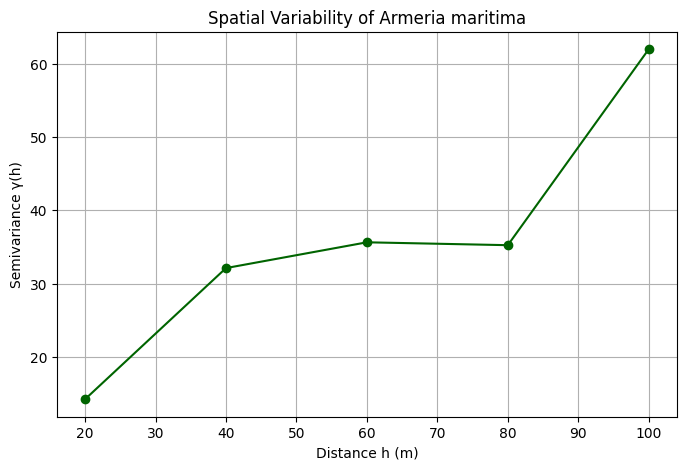

Lag Distance 20m: Semivariance = 14.22
Lag Distance 40m: Semivariance = 32.12
Lag Distance 60m: Semivariance = 35.64
Lag Distance 80m: Semivariance = 35.25
Lag Distance 100m: Semivariance = 62.00


In [ ]:
# Hints and Starting Code for Question 4.10

import numpy as np
import matplotlib.pyplot as plt

# Approach Hints:
# 1. Arrange the shoot counts in spatial order (e.g., as a function of distance along the profile).
# 2. Calculate pairwise distances between measurement points (assuming each square is at intervals of 20 m).
# 3. Compute the semivariogram γ(h) = 0.5 * mean[ (Z(x) - Z(x+h))^2 ] for each distance bin h.
# 4. Plot the semivariogram (γ on the y-axis vs. distance h on the x-axis) to see if there's any spatial structure.
# 5. Look for a sill, range, or nugget effect that might indicate how contamination (and thus sea thrift) is distributed.

import numpy as np
import matplotlib.pyplot as plt

# 1. Arrange the shoot counts in spatial order along the profile
# 20m x 20m squares
shoot_counts = np.array([3, 5, 11, 12, 8, 19, 22, 18, 11, 13])
dist_step = 20  # 20 meters per square

# 2. Calculate pairwise distances and semivariance for each lag h
lags = np.arange(1, 6)  # Calculating for the first 5 lags (100m)
gamma = []
h_distances = []

for h in lags:
    # Compute the differences between points separated by distance h
    # gamma(h) = 0.5 * mean[ (Z(x) - Z(x+h))^2 ]
    squared_diffs = (shoot_counts[h:] - shoot_counts[:-h])**2
    semivariance = 0.5 * np.mean(squared_diffs)

    gamma.append(semivariance)
    h_distances.append(h * dist_step)

# 3. Plot the semivariogram
plt.figure(figsize=(8, 5))
plt.plot(h_distances, gamma, 'o-', color='darkgreen', label='Experimental Semivariogram')
plt.xlabel('Distance h (m)')
plt.ylabel('Semivariance γ(h)')
plt.title('Spatial Variability of Armeria maritima')
plt.grid(True)
plt.show()

# 4. Output the specific values
for d, g in zip(h_distances, gamma):
    print(f"Lag Distance {d}m: Semivariance = {g:.2f}")


NOTE: Assignment Instructions say only 4.1 - 4.10

# Question 4.11

The following rock sequences are encountered in exploratory drilling:

- Claystone (C)  
- Conglomerate (K)  
- Sandstone (S)  
- Siltstone (U)

(See Table 4.5 for the per-meter breakdown.)

**Task:**  
1. What is the probability that conglomerate (K) will be drilled again in the *next* meter of drilling?  
2. What is the probability that conglomerate will be drilled again in the *next-but-one* meter of drilling?

You may assume that the encountered rock types can be treated as sequential observations of a Markov process or using simpler independence assumptions (depending on your interpretation of the problem’s statement).

In [ ]:
# Use this cell to start setting up your approach in Python.
# Possible steps:
# 1. Represent the rock sequences as a list or array.
# 2. Construct transition probabilities from the data if needed.
# 3. Calculate probabilities for "next meter" and "next-but-one meter."

import numpy as np

# HINT:
# - If you treat each meter drilled as a step in a Markov chain, you need a 4x4 transition matrix
#   (C, K, S, U) or some simpler approach based on frequencies.
# - Probability that K appears next might come directly from the row in the matrix corresponding
#   to the current rock type.
# - For the 'next-but-one' question, you might multiply transition matrices (e.g., T^2).

# Question 4.12

The following orientation data (dip direction α / dip β) for bedding planes are recorded (n=14):

123/25, 147/22, 120/24, 111/24, 142/26, 133/27, 135/22, 156/21,  
110/25, 101/25, 133/20, 123/22, 145/25, 126/24

**Task:**  
1. Determine the mean resultant length.  
2. Determine the dip direction and dip of the mean vector.  
3. Determine the spherical standard deviation and the spherical confidence interval of the mean vector for an error probability of α = 0.1.

In [ ]:
# Use this cell to load and process the orientation data.
# HINT:
# 1. Convert the dip direction/dip pairs into unit vectors in 3D space.
# 2. Sum these vectors, and derive the resultant direction and magnitude.
# 3. Calculate relevant statistics (standard deviation, confidence intervals) on a sphere.

import numpy as np

# Example structure:
# data = [(123,25), (147,22), (120,24), ...]
# Then convert each (alpha, beta) to x,y,z components on the unit sphere.
# Summation and geometry yield the mean vector direction and length.
#
# You might consider using spherical to Cartesian conversions:
# x = cos(dip) * sin(direction)
# y = cos(dip) * cos(direction)
# z = sin(dip)
# (in radians)